In [1]:
import pandas as pd

data = [
    ["E1",  "Sunny",    "Hot",  "High",   "Weak",   "No"],
    ["E2",  "Sunny",    "Hot",  "High",   "Strong", "No"],
    ["E3",  "Cloudy",   "Hot",  "High",   "Weak",   "Yes"],
    ["E4",  "Rainy",    "Mild", "High",   "Weak",   "Yes"],
    ["E5",  "Rainy",    "Cool", "Normal", "Weak",   "Yes"],
    ["E6",  "Rainy",    "Cool", "Normal", "Strong", "No"],
    ["E7",  "Cloudy",   "Cool", "Normal", "Strong", "Yes"],
    ["E8",  "Sunny",    "Mild", "High",   "Weak",   "No"],
    ["E9",  "Sunny",    "Cool", "Normal", "Weak",   "Yes"],
    ["E10", "Rainy",    "Mild", "Normal", "Weak",   "Yes"],
    ["E11", "Sunny",    "Mild", "Normal", "Strong", "Yes"],
    ["E12", "Cloudy",   "Mild", "High",   "Strong", "Yes"],
    ["E13", "Cloudy",   "Hot",  "Normal", "Weak",   "Yes"],
    ["E14", "Rainy",    "Mild", "High",   "Strong", "No"],
    ["E15", "Sunny",    "Cool", "High",   "Strong", "No"],
    ["E16", "Cloudy",   "Cool", "Normal", "Weak",   "Yes"],
]

columns = ["Example", "Outlook", "Temperature", "Humidity", "Wind", "Label"]

df = pd.DataFrame(data, columns=columns)

print("DATASET")
print(df)
print()


# ============================================================
# LEARN-ONE-RULE
# ============================================================
def learn_one_rule(data, positive_label="Yes", negative_label="No"):
    """
    Greedy general-to-specific rule learning.

    At every step:
        choose the attribute=value test maximizing

            p / (p + n)

    Ties are broken by larger p.

    Stop when n == 0.
    """

    # Start with an empty rule
    rule = {}

    attributes = [
        col for col in data.columns
        if col not in ["Example", "Label"]
    ]

    while True:

        # Examples satisfying the current rule
        covered = data.copy()

        for attr, value in rule.items():
            covered = covered[covered[attr] == value]

        p = len(covered[covered["Label"] == positive_label])
        n = len(covered[covered["Label"] == negative_label])

        # Stop when rule covers no negatives
        if n == 0:
            break

        # Find the best new condition
        best_test = None
        best_score = -1
        best_p = -1

        for attr in attributes:

            # Do not use the same attribute twice
            if attr in rule:
                continue

            for value in data[attr].unique():

                # Candidate rule
                candidate = data.copy()

                for old_attr, old_value in rule.items():
                    candidate = candidate[
                        candidate[old_attr] == old_value
                    ]

                candidate = candidate[candidate[attr] == value]

                candidate_p = len(
                    candidate[candidate["Label"] == positive_label]
                )

                candidate_n = len(
                    candidate[candidate["Label"] == negative_label]
                )

                # Ignore tests that cover no positive examples
                if candidate_p + candidate_n == 0:
                    continue

                score = candidate_p / (candidate_p + candidate_n)

                # Primary criterion: larger p/(p+n)
                # Tie breaker: larger p
                if (
                    score > best_score
                    or (score == best_score and candidate_p > best_p)
                ):
                    best_score = score
                    best_p = candidate_p
                    best_test = (attr, value)

        # No useful test found
        if best_test is None:
            break

        # Add selected condition
        rule[best_test[0]] = best_test[1]

    return rule


# ============================================================
# RULE APPLICATION
# ============================================================
def covers(rule, row):
    """Return True if a row satisfies all conditions in a rule."""

    for attr, value in rule.items():
        if row[attr] != value:
            return False

    return True


def rule_to_string(rule):
    """Convert dictionary rule to readable form."""

    if not rule:
        return "IF TRUE THEN Yes"

    conditions = [
        f"{attr} = {value}"
        for attr, value in rule.items()
    ]

    return "IF " + " AND ".join(conditions) + " THEN Yes"


# ============================================================
# SEQUENTIAL COVERING
# ============================================================
def sequential_covering(
    data,
    positive_label="Yes",
    negative_label="No"
):

    remaining = data.copy()

    rules = []

    round_number = 1

    while len(
        remaining[remaining["Label"] == positive_label]
    ) > 0:

        rule = learn_one_rule(
            remaining,
            positive_label,
            negative_label
        )

        # Find examples covered by rule
        covered = remaining[
            remaining.apply(
                lambda row: covers(rule, row),
                axis=1
            )
        ]

        # Positive examples covered
        covered_positive = covered[
            covered["Label"] == positive_label
        ]

        # Avoid infinite loops
        if len(covered_positive) == 0:
            break

        rules.append(rule)

        print("=" * 60)
        print(f"ROUND {round_number}")

        print("Learned rule:")
        print(rule_to_string(rule))

        print("\nPositive examples covered:")
        print(
            list(covered_positive["Example"])
        )

        # Remove all examples covered by the rule
        remaining = remaining[
            ~remaining.apply(
                lambda row: covers(rule, row),
                axis=1
            )
        ]

        print("\nExamples remaining:")
        print(list(remaining["Example"]))

        round_number += 1

    return rules


# ============================================================
# RUN SEQUENTIAL COVERING
# ============================================================

print("\nSEQUENTIAL COVERING")
print("=" * 60)

rules = sequential_covering(df)


# ============================================================
# ADD DEFAULT RULE
# ============================================================

print("\n\nCOMPLETE DECISION LIST")
print("=" * 60)

for i, rule in enumerate(rules, start=1):
    print(f"{i}. {rule_to_string(rule)}")

print(f"{len(rules) + 1}. ELSE -> No")


# ============================================================
# CLASSIFICATION USING DECISION LIST
# ============================================================

def classify(row, rules, default_label="No"):

    # Rules are checked from top to bottom
    for rule in rules:

        if covers(rule, row):
            return "Yes"

    return default_label


df["Prediction"] = df.apply(
    lambda row: classify(row, rules),
    axis=1
)

print("\nPREDICTIONS")
print("=" * 60)

print(
    df[["Example", "Label", "Prediction"]]
)


# ============================================================
# ACCURACY
# ============================================================

correct = (
    df["Label"] == df["Prediction"]
).sum()

total = len(df)

accuracy = correct / total

print("\nAccuracy:")
print(f"{correct}/{total} = {accuracy:.2%}")


# ============================================================
# NUMBER OF LITERALS IN EACH RULE
# ============================================================

print("\nRULE COMPLEXITY")
print("=" * 60)

for i, rule in enumerate(rules, start=1):

    print(
        f"Rule {i}: "
        f"{rule_to_string(rule)} "
        f"--> {len(rule)} literal(s)"
    )


# ============================================================
# EXPERIMENT: FLIP E6 FROM YES TO NO
# ============================================================

print("\n\nNOISE EXPERIMENT")
print("=" * 60)

noisy_df = df.drop(columns=["Prediction"]).copy()

# Change E6 from Yes to No
noisy_df.loc[
    noisy_df["Example"] == "E6",
    "Label"
] = "No"

print("Changed E6 label to No.")
print()

new_rules = sequential_covering(noisy_df)


print("\nNEW RULE SET AFTER FLIPPING E6")
print("=" * 60)

for i, rule in enumerate(new_rules, start=1):

    print(
        f"Rule {i}: "
        f"{rule_to_string(rule)} "
        f"--> {len(rule)} literal(s)"
    )

print(f"Default rule: ELSE -> No")


# ============================================================
# ACCURACY AFTER NOISE
# ============================================================

noisy_df["Prediction"] = noisy_df.apply(
    lambda row: classify(row, new_rules),
    axis=1
)

new_correct = (
    noisy_df["Label"] ==
    noisy_df["Prediction"]
).sum()

new_accuracy = new_correct / len(noisy_df)

print("\nAccuracy after changing E6:")
print(
    f"{new_correct}/{len(noisy_df)} = "
    f"{new_accuracy:.2%}"
)


DATASET
   Example Outlook Temperature Humidity    Wind Label
0       E1   Sunny         Hot     High    Weak    No
1       E2   Sunny         Hot     High  Strong    No
2       E3  Cloudy         Hot     High    Weak   Yes
3       E4   Rainy        Mild     High    Weak   Yes
4       E5   Rainy        Cool   Normal    Weak   Yes
5       E6   Rainy        Cool   Normal  Strong    No
6       E7  Cloudy        Cool   Normal  Strong   Yes
7       E8   Sunny        Mild     High    Weak    No
8       E9   Sunny        Cool   Normal    Weak   Yes
9      E10   Rainy        Mild   Normal    Weak   Yes
10     E11   Sunny        Mild   Normal  Strong   Yes
11     E12  Cloudy        Mild     High  Strong   Yes
12     E13  Cloudy         Hot   Normal    Weak   Yes
13     E14   Rainy        Mild     High  Strong    No
14     E15   Sunny        Cool     High  Strong    No
15     E16  Cloudy        Cool   Normal    Weak   Yes


SEQUENTIAL COVERING
ROUND 1
Learned rule:
IF Outlook = Cloudy THEN Yes



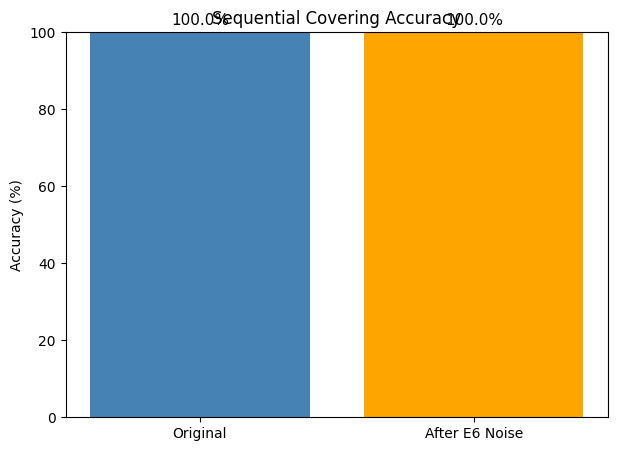

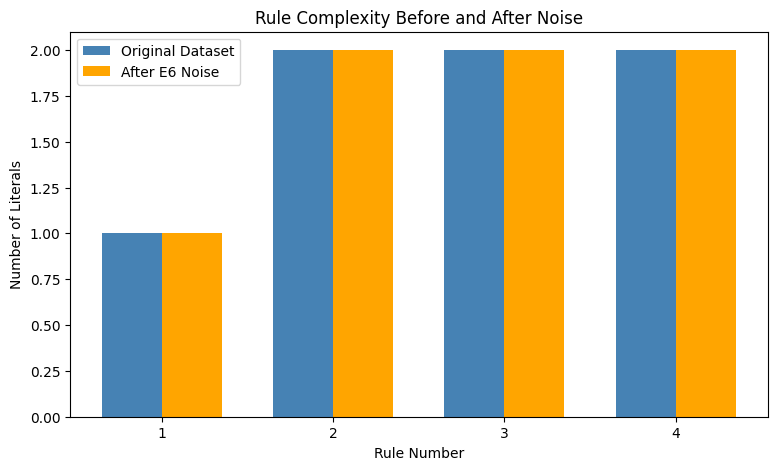

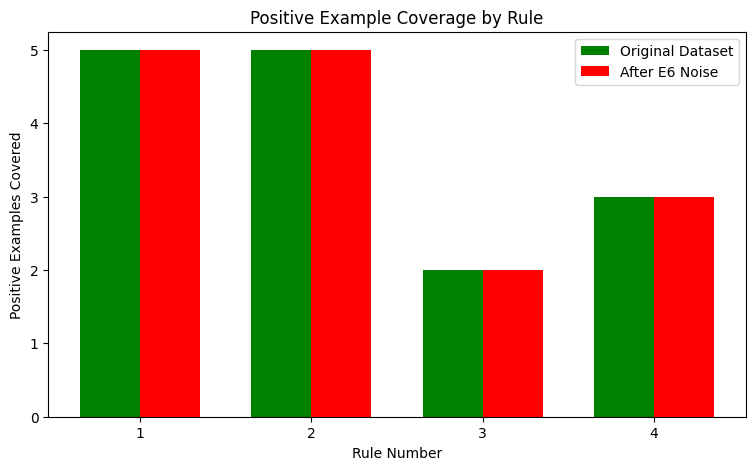

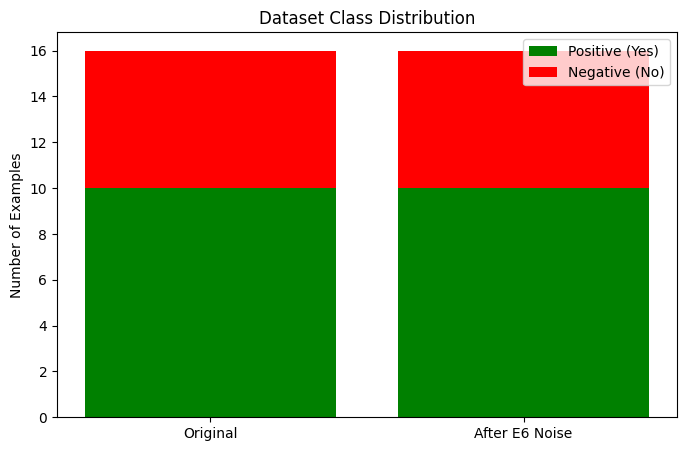

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# GRAPH 1: ACCURACY
# ============================================================

# Original accuracy
original_correct = (
    df["Label"] == df["Prediction"]
).sum()

original_accuracy = (
    original_correct / len(df)
) * 100

# Accuracy after noise
noisy_correct = (
    noisy_df["Label"] == noisy_df["Prediction"]
).sum()

noisy_accuracy = (
    noisy_correct / len(noisy_df)
) * 100


plt.figure(figsize=(7, 5))

datasets = ["Original", "After E6 Noise"]
accuracies = [
    original_accuracy,
    noisy_accuracy
]

bars = plt.bar(
    datasets,
    accuracies,
    color=["steelblue", "orange"]
)

plt.ylabel("Accuracy (%)")
plt.title("Sequential Covering Accuracy")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=11
    )

plt.show()


# ============================================================
# GRAPH 2: NUMBER OF LITERALS PER RULE
# ============================================================

original_literals = [
    len(rule)
    for rule in rules
]

noisy_literals = [
    len(rule)
    for rule in new_rules
]

max_rules = max(
    len(original_literals),
    len(noisy_literals)
)

rule_numbers = np.arange(
    1,
    max_rules + 1
)

# Fill missing values with 0
original_plot = (
    original_literals +
    [0] * (max_rules - len(original_literals))
)

noisy_plot = (
    noisy_literals +
    [0] * (max_rules - len(noisy_literals))
)


plt.figure(figsize=(9, 5))

width = 0.35

plt.bar(
    rule_numbers - width / 2,
    original_plot,
    width,
    label="Original Dataset",
    color="steelblue"
)

plt.bar(
    rule_numbers + width / 2,
    noisy_plot,
    width,
    label="After E6 Noise",
    color="orange"
)

plt.xlabel("Rule Number")
plt.ylabel("Number of Literals")
plt.title("Rule Complexity Before and After Noise")

plt.xticks(rule_numbers)
plt.legend()

plt.show()


# ============================================================
# GRAPH 3: POSITIVE EXAMPLES COVERED BY EACH RULE
# ============================================================

def positive_coverage(data, rule):

    covered = data[
        data.apply(
            lambda row: covers(rule, row),
            axis=1
        )
    ]

    return len(
        covered[covered["Label"] == "Yes"]
    )


original_coverage = [
    positive_coverage(df, rule)
    for rule in rules
]

noisy_coverage = [
    positive_coverage(noisy_df, rule)
    for rule in new_rules
]


max_rules = max(
    len(original_coverage),
    len(noisy_coverage)
)

rule_numbers = np.arange(
    1,
    max_rules + 1
)

original_coverage_plot = (
    original_coverage +
    [0] * (
        max_rules -
        len(original_coverage)
    )
)

noisy_coverage_plot = (
    noisy_coverage +
    [0] * (
        max_rules -
        len(noisy_coverage)
    )
)


plt.figure(figsize=(9, 5))

plt.bar(
    rule_numbers - width / 2,
    original_coverage_plot,
    width,
    label="Original Dataset",
    color="green"
)

plt.bar(
    rule_numbers + width / 2,
    noisy_coverage_plot,
    width,
    label="After E6 Noise",
    color="red"
)

plt.xlabel("Rule Number")
plt.ylabel("Positive Examples Covered")
plt.title("Positive Example Coverage by Rule")

plt.xticks(rule_numbers)
plt.legend()

plt.show()


# ============================================================
# GRAPH 4: NUMBER OF EXAMPLES
# ============================================================

positive_count = (
    df["Label"] == "Yes"
).sum()

negative_count = (
    df["Label"] == "No"
).sum()

noisy_positive_count = (
    noisy_df["Label"] == "Yes"
).sum()

noisy_negative_count = (
    noisy_df["Label"] == "No"
).sum()


categories = [
    "Original",
    "After E6 Noise"
]

positive_values = [
    positive_count,
    noisy_positive_count
]

negative_values = [
    negative_count,
    noisy_negative_count
]


plt.figure(figsize=(8, 5))

x = np.arange(
    len(categories)
)

plt.bar(
    x,
    positive_values,
    label="Positive (Yes)",
    color="green"
)

plt.bar(
    x,
    negative_values,
    bottom=positive_values,
    label="Negative (No)",
    color="red"
)

plt.xticks(
    x,
    categories
)

plt.ylabel("Number of Examples")
plt.title("Dataset Class Distribution")
plt.legend()

plt.show()
